## Random Forest

#### 1. Exploratory Data Analysis (EDA):

In [5]:
import pandas as pd
df = pd.read_excel("glass.xlsx", sheet_name="glass")
print(df.head())

print(df.tail())

print("Shape of dataset:", df.shape)

print("Columns:")
print(df.columns)

print(df.dtypes)

print(df.info())

print(df.describe())

print("Missing Values:")
print(df.isnull().sum())

print("Duplicate Rows:", df.duplicated().sum())

print("Glass Type Distribution:")
print(df['Type'].value_counts())

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1
          RI     Na   Mg    Al     Si     K    Ca    Ba   Fe  Type
209  1.51623  14.14  0.0  2.88  72.61  0.08  9.18  1.06  0.0     7
210  1.51685  14.92  0.0  1.99  73.06  0.00  8.40  1.59  0.0     7
211  1.52065  14.36  0.0  2.02  73.42  0.00  8.44  1.64  0.0     7
212  1.51651  14.38  0.0  1.94  73.61  0.00  8.48  1.57  0.0     7
213  1.51711  14.23  0.0  2.08  73.36  0.00  8.62  1.67  0.0     7
Shape of dataset: (214, 10)
Columns:
Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')
RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K     

In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Missing Values:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Duplicate Rows: 1
RI: 17 outliers
Na: 7 outliers
Mg: 0 outliers
Al: 18 outliers
Si: 12 outliers
K: 7 outliers
Ca: 26 outliers
Ba: 38 outliers
Fe: 12 outliers
Type: 29 outliers


#### 2: Data Visualization:

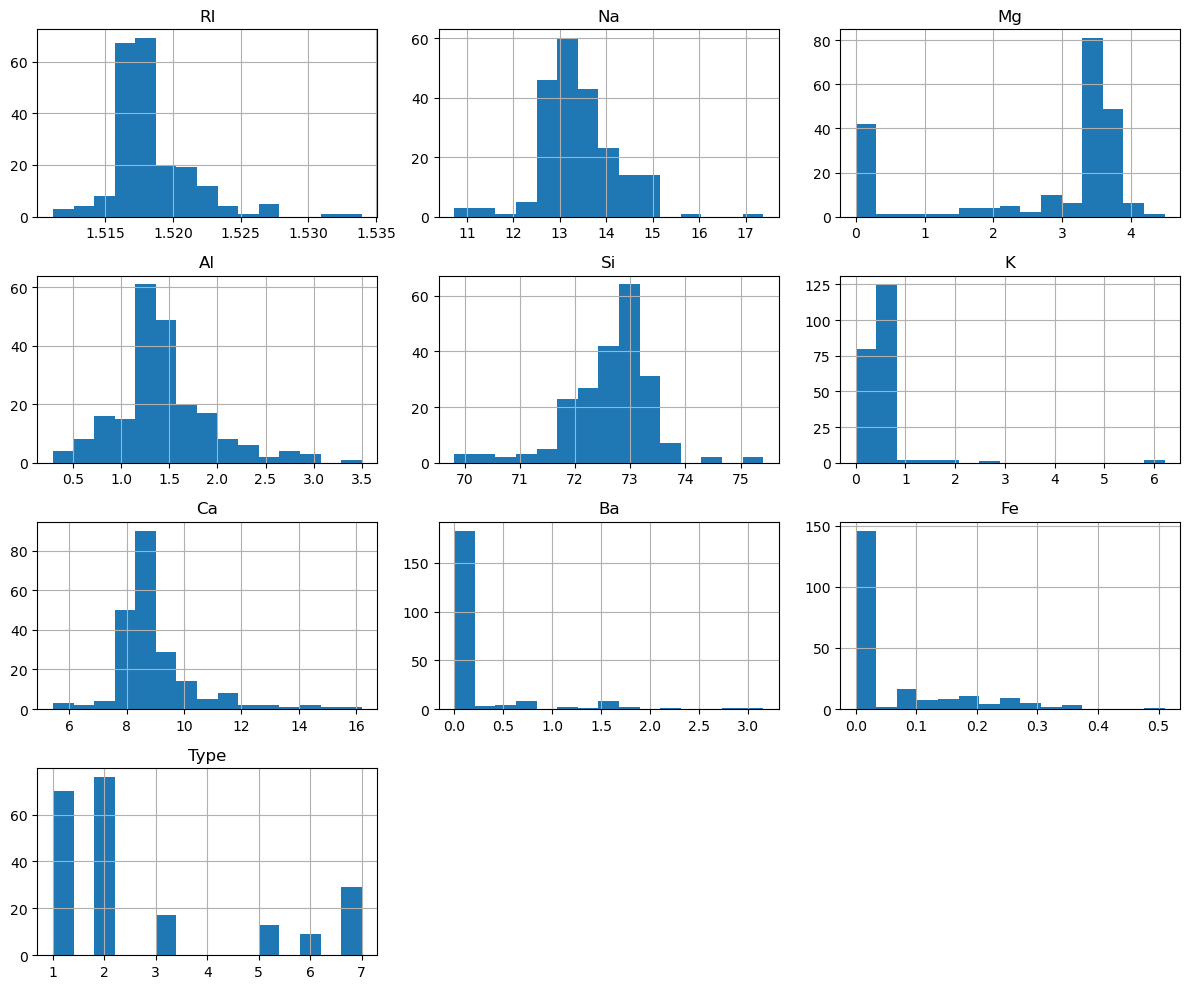

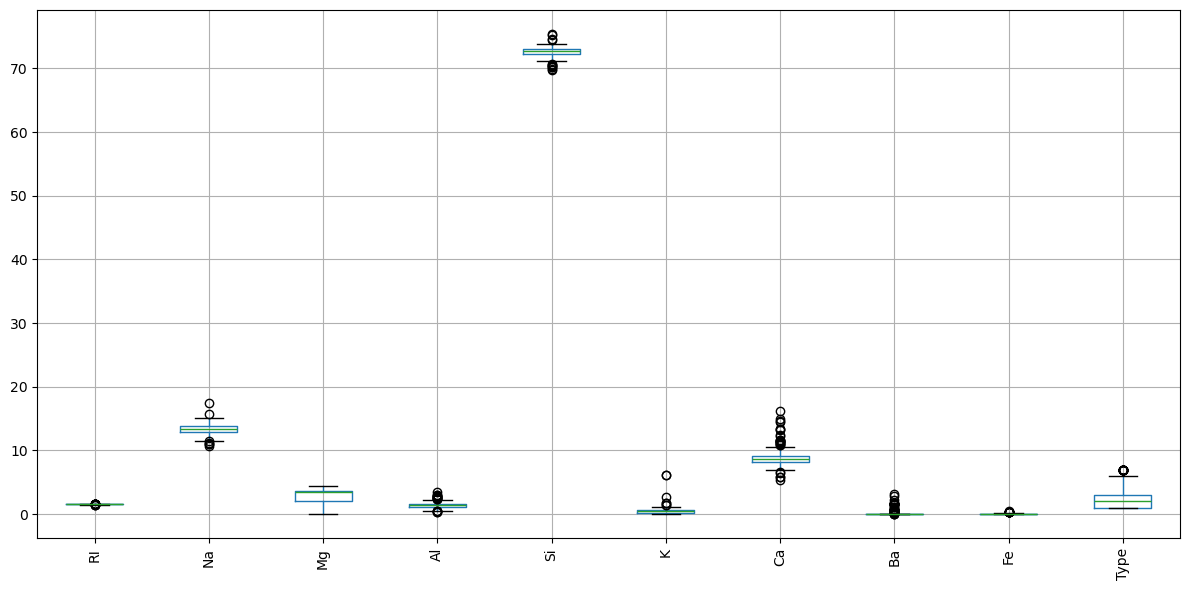

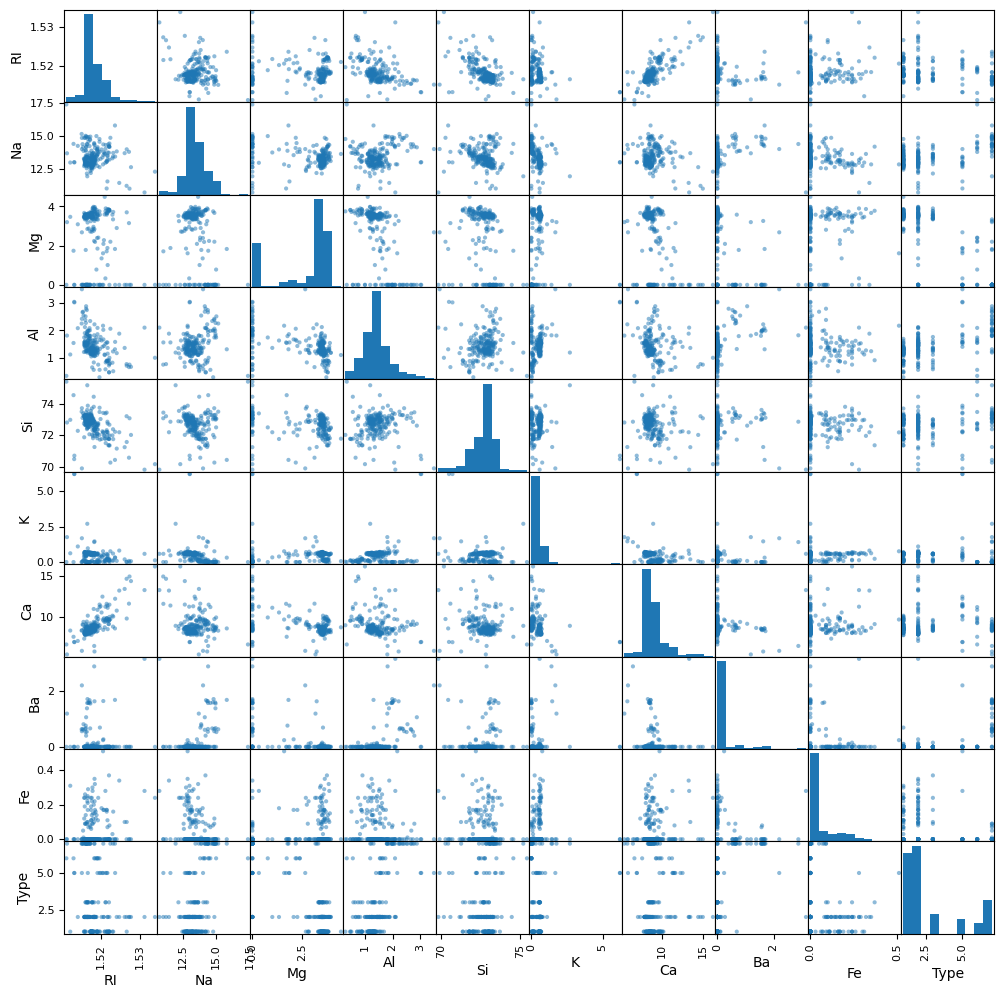

In [6]:
import matplotlib.pyplot as plt

df.hist(figsize=(12, 10), bins=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
df.boxplot(rot=90)
plt.tight_layout()
plt.show()

from pandas.plotting import scatter_matrix

scatter_matrix(df, figsize=(12, 12), diagonal='hist')
plt.show()

Correlation Matrix:
            RI        Na        Mg        Al        Si         K        Ca  \
RI    1.000000 -0.191885 -0.122274 -0.407326 -0.542052 -0.289833  0.810403   
Na   -0.191885  1.000000 -0.273732  0.156794 -0.069809 -0.266087 -0.275442   
Mg   -0.122274 -0.273732  1.000000 -0.481799 -0.165927  0.005396 -0.443750   
Al   -0.407326  0.156794 -0.481799  1.000000 -0.005524  0.325958 -0.259592   
Si   -0.542052 -0.069809 -0.165927 -0.005524  1.000000 -0.193331 -0.208732   
K    -0.289833 -0.266087  0.005396  0.325958 -0.193331  1.000000 -0.317836   
Ca    0.810403 -0.275442 -0.443750 -0.259592 -0.208732 -0.317836  1.000000   
Ba   -0.000386  0.326603 -0.492262  0.479404 -0.102151 -0.042618 -0.112841   
Fe    0.143010 -0.241346  0.083060 -0.074402 -0.094201 -0.007719  0.124968   
Type -0.164237  0.502898 -0.744993  0.598829  0.151565 -0.010054  0.000952   

            Ba        Fe      Type  
RI   -0.000386  0.143010 -0.164237  
Na    0.326603 -0.241346  0.502898  
Mg   -0.49

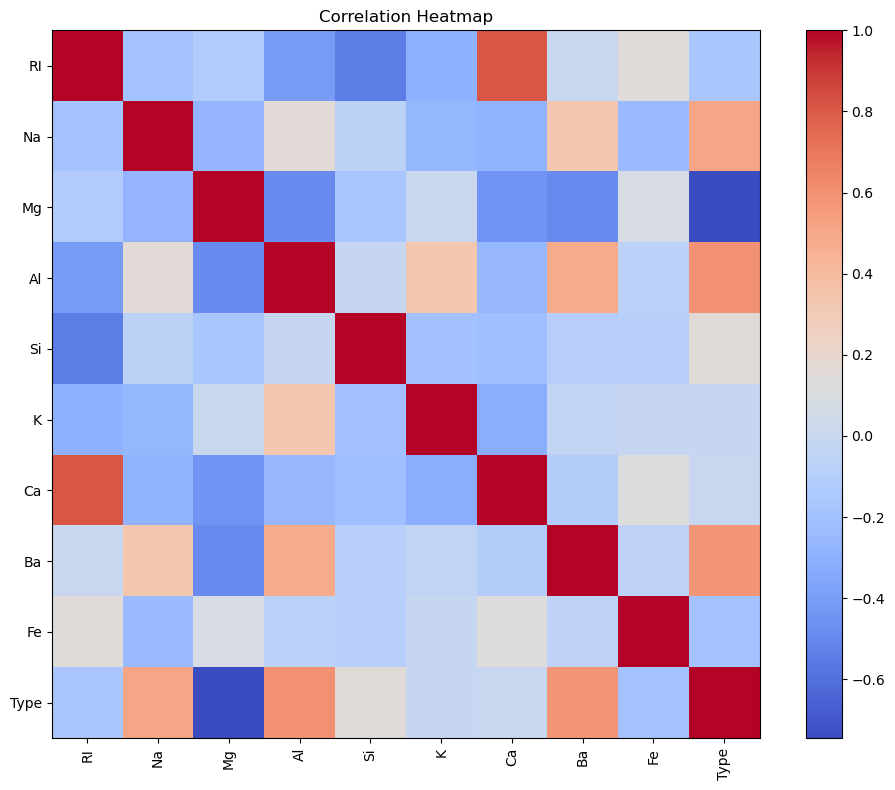


Patterns Observed:
- Some features show positive correlations, while others have weak or negative correlations.
- Features with high positive correlation tend to increase together.
- Most variables have low to moderate correlation, indicating limited multicollinearity.
- Outliers can be observed in a few numerical features from the box plots.


In [7]:
import matplotlib.pyplot as plt

correlation = df.corr(numeric_only=True)

print("Correlation Matrix:")
print(correlation)

plt.figure(figsize=(10, 8))
plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("\nPatterns Observed:")
print("- Some features show positive correlations, while others have weak or negative correlations.")
print("- Features with high positive correlation tend to increase together.")
print("- Most variables have low to moderate correlation, indicating limited multicollinearity.")
print("- Outliers can be observed in a few numerical features from the box plots.")

#### 3: Data Preprocessing

In [8]:
print("Missing Values:")
print(df.isnull().sum())

df = df.fillna(df.mean(numeric_only=True))

print("\nMissing Values After Handling:")
print(df.isnull().sum())

print("\nReason:")
print("Mean imputation is used because it preserves all records and is suitable for numerical features with a small number of missing values.")

Missing Values:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Missing Values After Handling:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Reason:
Mean imputation is used because it preserves all records and is suitable for numerical features with a small number of missing values.


In [9]:
print(df.select_dtypes(include=['object', 'category']).columns)

categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print("One-Hot Encoding Applied")
else:
    print("No categorical variables found. One-Hot Encoding is not required.")

Index([], dtype='object')
No categorical variables found. One-Hot Encoding is not required.


In [10]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Type", axis=1)
y = df["Type"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


In [11]:
print("Class Distribution Before Balancing:")
print(y.value_counts())

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

print("\nClass Distribution After Balancing:")
print(y_balanced.value_counts())

Class Distribution Before Balancing:
Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

Class Distribution After Balancing:
Type
1    76
2    76
3    76
5    76
6    76
7    76
Name: count, dtype: int64


#### 4: Random Forest Model Implementation

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.20,
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (364, 9)
Testing Features Shape: (92, 9)
Training Target Shape: (364,)
Testing Target Shape: (92,)


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [14]:
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1-Score :", f1_score(y_test, y_pred, average='weighted'))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.9239130434782609
Precision: 0.926268115942029
Recall   : 0.9239130434782609
F1-Score : 0.9234046297904994

Classification Report:
              precision    recall  f1-score   support

           1       0.87      0.76      0.81        17
           2       0.85      0.89      0.87        19
           3       0.83      1.00      0.91        10
           5       1.00      1.00      1.00        14
           6       1.00      1.00      1.00        14
           7       1.00      0.94      0.97        18

    accuracy                           0.92        92
   macro avg       0.93      0.93      0.93        92
weighted avg       0.93      0.92      0.92        92



#### 5: Bagging and Boosting Methods

In [15]:
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bagging.fit(X_train, y_train)
bag_pred = bagging.predict(X_test)

print("Bagging Results")
print("Accuracy :", accuracy_score(y_test, bag_pred))
print("Precision:", precision_score(y_test, bag_pred, average='weighted'))
print("Recall   :", recall_score(y_test, bag_pred, average='weighted'))
print("F1-Score :", f1_score(y_test, bag_pred, average='weighted'))

boosting = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

boosting.fit(X_train, y_train)
boost_pred = boosting.predict(X_test)

print("\nBoosting Results")
print("Accuracy :", accuracy_score(y_test, boost_pred))
print("Precision:", precision_score(y_test, boost_pred, average='weighted'))
print("Recall   :", recall_score(y_test, boost_pred, average='weighted'))
print("F1-Score :", f1_score(y_test, boost_pred, average='weighted'))

Bagging Results
Accuracy : 0.9130434782608695
Precision: 0.9171869193608323
Recall   : 0.9130434782608695
F1-Score : 0.9124297855583707

Boosting Results
Accuracy : 0.5434782608695652
Precision: 0.47456203217072784
Recall   : 0.5434782608695652
F1-Score : 0.4859146383745926


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


#### Additional Notes:

In [ ]:
1. Explain Bagging and Boosting methods. How is it different from each other.

Bagging (Bootstrap Aggregating):

Bagging is an ensemble learning technique that trains multiple models independently using different random samples of the training data.
The final prediction is obtained by combining the predictions of all models (majority voting for classification).
It mainly reduces variance and helps prevent overfitting.
Example: Random Forest.

Boosting:

Boosting is an ensemble learning technique where models are trained sequentially.
Each new model focuses on correcting the errors made by the previous model.
The final prediction is a weighted combination of all models.
It mainly reduces bias and improves predictive accuracy.
Examples: AdaBoost, Gradient Boosting, XGBoost.

Bagging                                                                     

 Models are trained independently.      
 Uses random bootstrap samples.       
 Reduces variance.                     
 Less sensitive to noise and outliers. 
 Example: Random Forest.               

Boosting     

Models are trained sequentially. 
Each model learns from previous model's errors.
Reduces bias.
More sensitive to noise and outliers. 
Example: AdaBoost.

In [ ]:
2. Explain how to handle imbalance in the data.

Imbalanced data occurs when one class has significantly more samples than the other classes, which can lead to biased model predictions.

Common techniques to handle imbalanced data include:

Random Oversampling: Increases the number of samples in the minority class by duplicating existing samples.
Random Undersampling: Reduces the number of samples in the majority class to balance the dataset.
SMOTE (Synthetic Minority Over-sampling Technique): Generates synthetic samples for the minority class instead of duplicating existing ones.
Class Weighting: Assigns higher weights to minority class samples during model training.
Ensemble Methods: Techniques such as Balanced Random Forest and EasyEnsemble are designed to work effectively with imbalanced datasets.